Geoinformatik 2 – GIS-Analyse
# Übung 12: Analyse der Verkehrserreichbarkeit in Mainz
Prof. Dr. Yu Feng

In der Sozialraumanalyse ist die Verkehrserreichbarkeit ein entscheidender Faktor zur Bewertung von Mobilitätschancen, Stadtplanung und sozialer Gerechtigkeit. Durch die Untersuchung der Erreichbarkeit öffentlicher Einrichtungen, Verkehrsanbindungen und urbaner Infrastrukturen können Städte nachhaltiger und gerechter gestaltet werden.

In diesem Notebook lernen wir, wie man die Verkehrserreichbarkeit mit Python und GIS analysiert und visualisiert. Dabei nutzen wir verschiedene Bibliotheken zur Geodatenverarbeitung und Kartendarstellung, um Mobilitätsmuster und Erreichbarkeitszonen zu berechnen.

**Referenz:**
- r5py – rapid realistic routing with Python. https://r5py.readthedocs.io/en/stable/
- Pönkänen, M., Tenkanen, H., & Mladenović, M. (2025). Spatial accessibility and transport inequity in Finland: Open source models and perspectives from planning practice. Computers, Environment and Urban Systems, 116, 102218.
- Spatial data science for sustainable development. https://sustainability-gis.readthedocs.io/en/latest/


## **Inhaltsverzeichnis**
1. Geodaten laden & vorbereiten
2. Erstellung eines Verkehrsnetzwerks
3. Analyse 1: Reisezeit-berechnung von Mainz Hbf zu allen Zielen
4. Analyse 2: Reisezeiten zu Bibliotheken für die gesamte Stadt

#### **Installation der benötigten Bibliotheken**
In diesem Schritt installieren wir die für die Analyse notwendigen Python-Bibliotheken. Dazu gehören Rasterverarbeitung, GIS-Datenverarbeitung und Routing-Werkzeuge.

In [1]:
#!pip install rasterio
#!pip install rasterstats
#!pip install osmnx
#!pip install "h3<4.0.0"
#!pip install pyrosm
#!pip install r5py
#!pip install geojson

#### **Import relevanter Bibliotheken und Festlegen der Speicherparameter**

Hier werden wichtige Bibliotheken importiert und Speichereinstellungen vorgenommen, um die Verarbeitung großer Datensätze zu optimieren.


In [3]:
import sys
sys.argv.append(["--max-memory", "7G"])

import numpy as np
import geopandas as gpd

### **1. Geodaten laden & vorbereiten**

Wir laden eine GeoJSON-Datei unserer Untersuchungsregion **Mainz** und visualisieren diese auf einer interaktiven Karte.

In [4]:
filename = "Data/mainz.geojson"
df = gpd.read_file(filename)
df.explore(tiles="OpenStreetMap", height=500, width=1000)

#### **Erstellung geeigneter geometrischer Analyseeinheiten**

Um die Stadt in kleinere Analyseeinheiten zu unterteilen, erstellen wir ein **räumliches Raster**. Dies kann entweder ein reguläres Gitter (**Grid**) oder ein **hexagonales Raster** sein.  

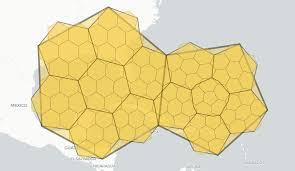

Wir nutzen **H3-Hexagone**, weil sie folgende Vorteile bieten:  

- **Bessere räumliche Kontinuität**  
  Hexagone haben keine abrupten Kanten wie quadratische Raster, was sie ideal für Mobilitäts- und Erreichbarkeitsanalysen macht.  

- **Gleichmäßige Nachbarschaftsverhältnisse**  
  Jede Hexagon-Zelle hat immer **sechs benachbarte Zellen**, was zu einer **gleichmäßigeren Analyse** führt.  

- **Vermeidung von Verzerrungen**  
  Im Gegensatz zu rechteckigen Gittern, die in geographischen Projektionen oft **verzerrt** werden, bleiben Hexagone in vielen Projektionen **gleichmäßig verteilt**.  

Durch diese Eigenschaften eignen sich **H3-Hexagone besonders gut für die Modellierung von Erreichbarkeitszonen**.  

In [5]:
import shapely
from shapely.geometry import Polygon
from shapely.ops import unary_union

import h3

# Berechnung der vereinheitlichten Geometrie für das Untersuchungsgebiet (AOI - Area of Interest)
feature_geom = unary_union(df.iloc[0]['geometry'])

# Umwandlung in das GeoJSON-Format
feature = {
    "type": "Feature",
    "properties": {},
    "geometry": shapely.geometry.mapping(feature_geom),
}

# Umkehrung der Koordinaten (lat, lon → lon, lat) zur Einhaltung der GeoJSON-Spezifikation
def swap_lat_lon(coords):
    return [[lon, lat] for lat, lon in coords]

# Verarbeitung von Polygon- und MultiPolygon-Geometrien
if feature['geometry']['type'] == "Polygon":
    feature['geometry']['coordinates'] = [swap_lat_lon(ring) for ring in feature['geometry']['coordinates']]
elif feature['geometry']['type'] == "MultiPolygon":
    feature['geometry']['coordinates'] = [[swap_lat_lon(ring) for ring in polygon] for polygon in feature['geometry']['coordinates']]

# Generierung von H3-Hexagonen basierend auf der definierten Fläche
hexagons = list(h3.polyfill(feature['geometry'], 9))

# Umwandlung der H3-Hexagone in Polygon-Geometrien
geoms = [Polygon(h3.h3_to_geo_boundary(hex_id, geo_json=True)) for hex_id in hexagons]

# Erstellung eines GeoDataFrame und Festlegung des CRS (Koordinatenreferenzsystems)
hex_df = gpd.GeoDataFrame(geometry=geoms, columns=["id"])
hex_df["id"] = hex_df.index
hex_df.set_crs(epsg=4326, inplace=True)
hex_df.head()

,id,geometry
0,0,"POLYGON ((8.30722 49.94938, 8.30746 49.94771, ..."
1,1,"POLYGON ((8.23913 49.92177, 8.23937 49.92009, ..."
2,2,"POLYGON ((8.2539 49.93607, 8.25414 49.9344, 8...."
3,3,"POLYGON ((8.20736 50.00994, 8.2076 50.00827, 8..."
4,4,"POLYGON ((8.28463 49.99023, 8.28487 49.98856, ..."


In [5]:
# Interaktive Visualisierung des generierten Hexagon-Rasters
hex_df.explore(height=500, width=1000)

#### **Laden und Verarbeiten von Bevölkerungsdaten**  

Um die **Bevölkerungsverteilung** in unserem Untersuchungsgebiet zu analysieren, verwenden wir [**WorldPop Deutschland 2020**](https://hub.worldpop.org/geodata/summary?id=49977).  

- **WorldPop** ist ein hochaufgelöster Datensatz, der die geschätzte Bevölkerungsverteilung basierend auf Rasterzellen darstellt.  
- Wir nutzen diesen Datensatz, um die **Gesamtbevölkerung pro Hexagon-Zelle** zu berechnen.  
- Dazu wenden wir **zonal statistics** an, um die Rasterwerte (Bevölkerung) auf die vordefinierten Hexagon-Zellen zu aggregieren.  

Diese Berechnung hilft uns dabei, **die Erreichbarkeit von Infrastrukturen im Verhältnis zur Bevölkerung zu bewerten**, indem wir herausfinden, wie viele Menschen in bestimmten Gebieten leben.

In [6]:
import rasterio
import rasterio.mask
from rasterstats import zonal_stats

# Öffnen des Bevölkerungs-Rasterdatensatzes (GeoTIFF)
raster_path = "Data/deu_ppp_2020_UNadj_constrained.tif"  # Pfad zur Rasterdatei
with rasterio.open(raster_path) as src:
    affine = src.transform  # Extrahieren der Affinentransformation des Rasters
    raster_data = src.read(1)  # Laden der Daten des ersten Bands

# Berechnung der Gesamtbevölkerung innerhalb jeder Hexagon-Zelle
stats = zonal_stats(hex_df, raster_path, stats=["sum"], affine=affine)

# Hinzufügen der berechneten Bevölkerungswerte zum GeoDataFrame
hex_df["population_sum"] = [s["sum"] if s["sum"] is not None else 0 for s in stats]
hex_df.head()

,id,geometry,population_sum
0,0,"POLYGON ((8.30722 49.94938, 8.30746 49.94771, ...",37.883404
1,1,"POLYGON ((8.23913 49.92177, 8.23937 49.92009, ...",0.000000
2,2,"POLYGON ((8.2539 49.93607, 8.25414 49.9344, 8....",0.000000
3,3,"POLYGON ((8.20736 50.00994, 8.2076 50.00827, 8...",501.750458
4,4,"POLYGON ((8.28463 49.99023, 8.28487 49.98856, ...",366.891907


 Hier vergleichen wir die **Bevölkerungszahl aus der WorldPop-Schätzung (2020)** mit den aktuellen **Angaben aus [Wikipedia (2023)](https://de.wikipedia.org/wiki/Mainz)**:  

- **Wikipedia-Daten**: Die offizielle Bevölkerungszahl von Mainz zum 31. Dezember 2023 beträgt **222.889**.  

In [7]:
print("Population from Worldpop (2020):", int(hex_df["population_sum"].sum()))

Population from Worldpop (2020): 231544


In [8]:
# Interaktive Karte zur Darstellung der Gesamtbevölkerung pro Hexagon-Zelle
hex_df.explore(column="population_sum", cmap="OrRd", legend=True, height=500, width=1000)

Um bestimmte Analysen durchzuführen, benötigen wir **repräsentative Punkte** für jede Hexagon-Zelle.  

- **Zentroid-Berechnung**: Wir extrahieren die **Zentren (Centroids)** der Hexagon-Polygone, um diese als Punkte zu verwenden.  

In [9]:
# Umwandlung der Hexagon-Polygone in Punktgeometrien (Zentroid)
points = hex_df.copy()
points["geometry"] = points.centroid  # Berechnung der Zentren der Hexagon-Zellen
points.set_crs(epsg=4326, inplace=True)
points.head()

/var/folders/56/_0_zr2cn2wbbnf3z1v7_rs000000gn/T/ipykernel_41160/3496168855.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  points["geometry"] = points.centroid  # Berechnung der Zentren der Hexagon-Zellen


,id,geometry,population_sum
0,0,POINT (8.3097 49.9488),37.883404
1,1,POINT (8.24162 49.92118),0.000000
2,2,POINT (8.25638 49.93548),0.000000
3,3,POINT (8.20985 50.00936),501.750458
4,4,POINT (8.28712 49.98964),366.891907


In [10]:
points.explore(column="population_sum", max_zoom=13, color="red", height=500, width=1000)  # Visualisierung der Punkte auf einer interaktiven Karte

### **2. Erstellung eines Verkehrsnetzwerks**  

Hier laden wir das **Verkehrsnetz der Stadt Mainz** aus **OpenStreetMap (OSM)**, um es für Erreichbarkeitsanalysen und Routing-Berechnungen zu nutzen.  

- **pyrosm** ermöglicht eine schnelle Verarbeitung großer OSM-Daten, einschließlich Straßennetzen und öffentlichem Verkehr.  
- Mit `get_data("Mainz")` laden wir die OSM-Daten für Mainz, die Informationen zu **Straßen, Wegen und Verkehrsnetzen** enthalten.  
- Die Datei wird anschließend mit `OSM(osm_fp)` verarbeitet, um später spezifische **Verkehrsinfrastrukturen wie Straßen, Radwege und ÖPNV-Netze** zu extrahieren.  

In [1]:
from pyrosm import OSM, get_data

# Abruf der Verkehrsnetz-Daten für Mainz aus OpenStreetMap
osm_fp = get_data("Mainz")  # Laden der OSM-Daten für die Stadt Mainz
osm = OSM(osm_fp)  # Initialisierung des OSM-Objekts zur Verarbeitung des Verkehrsnetzes

#### **Erstellung eines Verkehrsnetzwerks mit OSM- und GTFS-Daten**  

Um das **Verkehrsnetzwerk** für Mainz zu modellieren, kombinieren wir **OpenStreetMap (OSM)**-Daten mit **GTFS-Daten für den öffentlichen Nahverkehr**.  

- **OSM-Daten** enthalten Informationen über das **Straßennetz, Gehwege und Radwege**.  
- **GTFS-Daten** liefern Fahrpläne und Routeninformationen für **Busse, Bahnen und andere öffentliche Verkehrsmittel**.  

Zur **Einbindung beider Datensätze** nutzen wir `r5py.TransportNetwork`, indem wir die Dateipfade zum **OSM-Extrakt** und zu den **GTFS-Dateien** angeben.  


In [2]:
import r5py
from r5py import TransportNetwork

#%%time
transport_network = TransportNetwork(
    # OSM data
    osm_fp, 
    
    # A list of GTFS file(s)
    ["Data/latest.zip", "Data/latest_re_s.zip"]
)
print("Prepared the network")

Prepared the network


### **3. Analyse 1 – Von einem Standort zu allen Zielen mit öffentlichem Nahverkehr**  

In dieser Analyse berechnen wir die **Erreichbarkeit des Mainz Hauptbahnhofs** mithilfe des **öffentlichen Nahverkehrs**.  

- Der **Zielort** ist der **Mainz Hauptbahnhof**, der als zentraler Verkehrsknotenpunkt für **Zug-, Bus- und Straßenbahnverbindungen** dient.  
- Die Berechnung erfolgt auf Basis eines **multimodalen Verkehrsnetzwerks**, das sowohl **Fußwege als auch den öffentlichen Nahverkehr** berücksichtigt.  
- Als Ergebnis erhalten wir eine **Reisezeitmatrix**, die zeigt, welche Orte innerhalb eines bestimmten Zeitrahmens den Hauptbahnhof erreichen können.  

In [10]:
import osmnx as ox
from shapely.geometry import Point 

address = "Mainz Hauptbahnhof, Mainz, Germany"
lat, lon = ox.geocode(address)

# Create a GeoDataFrame out of the coordinates
origin = gpd.GeoDataFrame({"geometry": [Point(lon, lat)], "name": "Mainz Hbf", "id": [0]}, index=[0], crs="epsg:4326")
origin.explore(max_zoom=13, color="red", marker_kwds={"radius": 12}, height=500, width=1000)

Hier wird eine **Reisezeitmatrix** berechnet, die die Erreichbarkeit von verschiedenen Orten über den **öffentlichen Nahverkehr** bestimmt.  

- **Start- und Zielorte:**  
  - Der **Startpunkt (origins)** ist ein einzelner Standort, z. B. der Mainz Hauptbahnhof.  
  - Die **Zielorte (destinations)** sind alle Punkte innerhalb des Untersuchungsgebiets.  

- **Abfahrtszeitpunkt:**  
  - Die Analyse wird für den **19. Februar 2025 um 8:30 Uhr** durchgeführt.  
  - Diese Zeit wurde gewählt, um typische Pendelzeiten zu simulieren.  

- **Berücksichtigte Verkehrsmittel:**  
  - **TRANSIT**: Alle öffentlichen Verkehrsmittel (allgemein).  
  - **RAIL**: Regional- und Fernzüge.  
  - **SUBWAY**: U-Bahn-Netze.  
  - **TRAM**: Straßenbahnen.  
  - **WALK**: Fußwege für die letzte Meile oder zur Verbindung von Haltestellen.  

- **Ergebnis:**  
  - Die Funktion `compute_travel_times()` berechnet die **geschätzten Reisezeiten** von einem Startpunkt zu allen Zielorten.  
  - Das Ergebnis wird als **Tabelle (DataFrame)** gespeichert, die die ersten Zeilen mit `.head()` anzeigt.  

In [11]:
import datetime
from r5py import TravelTimeMatrixComputer, TransportMode

# Initialisierung des Tools zur Berechnung der Reisezeiten
travel_time_matrix_computer = TravelTimeMatrixComputer(
    transport_network,
    origins=origin,  # Ausgangspunkt der Analyse
    destinations=points,  # Zielorte innerhalb des Untersuchungsgebiets
    departure=datetime.datetime(2025, 2, 19, 8, 30),  # Abfahrtszeitpunkt: 19. Februar 2025 um 8:30 Uhr
    transport_modes=[TransportMode.TRANSIT,  # Allgemeiner öffentlicher Verkehr
                     TransportMode.RAIL,  # Regional- und Fernzüge
                     TransportMode.SUBWAY,  # U-Bahn
                     TransportMode.TRAM,  # Straßenbahn
                     TransportMode.WALK],  # Fußwege für die letzte Meile
)

# Berechnung der Reisezeiten
travel_time_matrix = travel_time_matrix_computer.compute_travel_times()

# Anzeige der ersten Zeilen der berechneten Reisezeitmatrix
travel_time_matrix.head()

/var/folders/56/_0_zr2cn2wbbnf3z1v7_rs000000gn/T/ipykernel_41160/320307675.py:5: DeprecationWarning: Use `TravelTimeMatrix` instead, `TravelTimeMatrixComputer will be deprecated in a future release.
  travel_time_matrix_computer = TravelTimeMatrixComputer(


,from_id,to_id,travel_time
0,0,0,50.0
1,0,1,60.0
2,0,2,53.0
3,0,3,31.0
4,0,4,26.0


 Hier verknüpfen wir die **berechnete Reisezeitmatrix** mit dem **Hexagon-Raster**, um die Reisezeiten für jede räumliche Einheit sichtbar zu machen.  

- **Datenverknüpfung:**  
  - `hex_df` enthält die **geometrischen Hexagon-Zellen** des Untersuchungsgebiets.  
  - `travel_time_matrix` enthält die **Reisezeiten von einem Startpunkt zu den einzelnen Zielzellen**.  
  - Die Verknüpfung erfolgt über die Spalten:
    - `left_on="id"`: Die ID der Hexagon-Zellen.  
    - `right_on="to_id"`: Die ID der Zielorte in der Reisezeitmatrix.  

- **Ziel der Verknüpfung:**  
  - Die **Reisezeiten werden in den Hexagon-Datenrahmen integriert**, sodass jede Zelle eine zugehörige Erreichbarkeitsinformation erhält.  
  - Dies ermöglicht die **räumliche Visualisierung der Erreichbarkeit** auf einer Karte.  

In [12]:
# Verknüpfung der Reisezeitmatrix mit dem Hexagon-Datenrahmen
join = hex_df.merge(travel_time_matrix, 
                    left_on="id", right_on="to_id")

# Anzeige der ersten Zeilen der kombinierten Daten
join.head()

,id,geometry,population_sum,from_id,to_id,travel_time
0,0,"POLYGON ((8.30722 49.94938, 8.30746 49.94771, ...",37.883404,0,0,50.0
1,1,"POLYGON ((8.23913 49.92177, 8.23937 49.92009, ...",0.000000,0,1,60.0
2,2,"POLYGON ((8.2539 49.93607, 8.25414 49.9344, 8....",0.000000,0,2,53.0
3,3,"POLYGON ((8.20736 50.00994, 8.2076 50.00827, 8...",501.750458,0,3,31.0
4,4,"POLYGON ((8.28463 49.99023, 8.28487 49.98856, ...",366.891907,0,4,26.0


Hier erstellen wir eine **interaktive Karte**, die die **Reisezeit zu verschiedenen Standorten** in der Untersuchungsregion visualisiert.  

- **Visualisierung der Reisezeiten:**  
  - **Choroplethenkarte:** Die Hexagon-Zellen werden basierend auf ihrer **Reisezeit zum Startpunkt** farblich kodiert.  
  - **Farbskala:** Die Farben reichen von **Gelb (kurze Reisezeit) bis Grün (längere Reisezeit)**.  
  - **Definierte Zeitintervalle:** Die Skalierung erfolgt in **15-Minuten-Schritten bis 180 Minuten**, um eine differenzierte Analyse zu ermöglichen.  


In [13]:
import matplotlib
import folium
import folium.plugins
from geojson import Feature, Point, FeatureCollection
import json

m = origin.explore(zoom_start=12, max_zoom=15, color="red", 
                   marker_kwds={"radius": 10}, tiles="cartodbpositron", 
                   height=700, width=1000)

custom_scale = [0,15.0,30.0,45.0,60.0,75.0,90.0,105.0,120.0, 180.0]
    
cp = folium.Choropleth(
        geo_data=join,
        name="travel time",
        data=join["travel_time"],
        popup=join["travel_time"],
        key_on="id",
        threshold_scale=custom_scale,
        fill_color="YlGn",
        fill_opacity=0.5,
        line_opacity=0.01,
        legend_name="Travel time (min)",
    ).add_to(m)

m

### **Analyse 2 – Von einem Standorttyp zu allen Zielen mit öffentlichem Nahverkehr**  

Hier analysieren wir die **Erreichbarkeit öffentlicher Bibliotheken in Mainz** und berechnen, **wie viele Bürger innerhalb von 15 Minuten** eine Bibliothek erreichen können.  

In [14]:
# Fetch libraries from multiple cities simultaneously
query = ["Mainz, Germany"]
libraries = ox.features_from_place(query, tags={"amenity": ["library"]})

# Convert the geometries to points
libraries["geometry"] = libraries.centroid

# Ensure that every row have an unique id
libraries = libraries.reset_index()
libraries["id"] = libraries.index
libraries.head()

/var/folders/56/_0_zr2cn2wbbnf3z1v7_rs000000gn/T/ipykernel_41160/2931798313.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  libraries["geometry"] = libraries.centroid


,element,id,geometry,addr:city,addr:housenumber,addr:postcode,addr:street,amenity,check_date,internet_access,...,roof:levels,wikimedia_commons,wikipedia,addr:country,type,alt_name,short_name,unimainz:buildingId,wheelchair:description,toilets:wheelchair
0,node,0,POINT (8.24083 49.99486),Mainz,12,55128,Jakob-Welder-Weg,library,2025-07-25,wlan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,node,1,POINT (8.24258 49.9939),NaN,NaN,NaN,NaN,library,NaN,wlan,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,node,2,POINT (8.23248 49.99131),NaN,NaN,NaN,NaN,library,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,node,3,POINT (8.31228 49.9624),NaN,NaN,NaN,NaN,library,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,node,4,POINT (8.20878 50.00196),NaN,NaN,NaN,NaN,library,2025-09-14,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
libraries.explore(color="red", marker_kwds=dict(radius=5))

Hier wird eine **Reisezeitmatrix für öffentliche Bibliotheken** berechnet, um die **Erreichbarkeit dieser Standorte** innerhalb von Mainz zu analysieren.  

- **Start- und Zielorte:**  
  - **Startpunkte (origins):** Öffentliche **Bibliotheken** in Mainz.  
  - **Zielorte (destinations):** Alle definierten Punkte in der Untersuchungsregion.  

- **Abfahrtszeitpunkt:**  
  - Die Analyse wird für den **19. Februar 2025 um 8:30 Uhr** durchgeführt.  

- **Berücksichtigte Verkehrsmittel:**  
  - **TRANSIT:** Alle öffentlichen Verkehrsmittel.  
  - **RAIL:** Regional- und Fernzüge.  
  - **SUBWAY:** U-Bahn-Netze.  
  - **TRAM:** Straßenbahnen.  
  - **WALK:** Fußwege für die letzte Meile oder zur Verbindung von Haltestellen.  

In [16]:
import datetime
from r5py import TravelTimeMatrixComputer, TransportMode

# Initialisierung des Tools zur Berechnung der Reisezeiten zu Bibliotheken
travel_time_matrix_computer = TravelTimeMatrixComputer(
    transport_network,
    origins=libraries,  # Startpunkte: Öffentliche Bibliotheken in Mainz
    destinations=points,  # Zielorte: Alle analysierten Standorte innerhalb der Stadt
    departure=datetime.datetime(2025, 2, 19, 8, 30),  # Abfahrtszeitpunkt: 19. Februar 2025 um 8:30 Uhr
    transport_modes=[TransportMode.TRANSIT,  # Allgemeiner öffentlicher Verkehr
                     TransportMode.RAIL,  # Regional- und Fernzüge
                     TransportMode.SUBWAY,  # U-Bahn
                     TransportMode.TRAM,  # Straßenbahn
                     TransportMode.WALK],  # Fußwege für die letzte Meile
)

# Berechnung der Reisezeiten
travel_time_matrix = travel_time_matrix_computer.compute_travel_times()

# Anzeige der ersten Zeilen der berechneten Reisezeitmatrix
travel_time_matrix.head()

/var/folders/56/_0_zr2cn2wbbnf3z1v7_rs000000gn/T/ipykernel_41160/3733061626.py:5: DeprecationWarning: Use `TravelTimeMatrix` instead, `TravelTimeMatrixComputer will be deprecated in a future release.
  travel_time_matrix_computer = TravelTimeMatrixComputer(


,from_id,to_id,travel_time
0,0,0,55.0
1,0,1,75.0
2,0,2,66.0
3,0,3,31.0
4,0,4,40.0


Hier berechnen wir die **Reisezeit zur nächstgelegenen öffentlichen Bibliothek** für jeden analysierten Standort.  


Die **Reisezeitmatrix** enthält Reisezeiten von mehreren Bibliotheken zu verschiedenen Zielorten. Mit `groupby("to_id")["travel_time"].min()` gruppieren wir die Daten nach **Ziel-ID (`to_id`)** und wählen die **geringste Reisezeit**. `reset_index()` stellt sicher, dass das Ergebnis als neuer DataFrame vorliegt.

In [17]:
# Ermittlung der Reisezeit zur nächstgelegenen Bibliothek
closest_library = travel_time_matrix.groupby("to_id")["travel_time"].min().reset_index()

# Anzeige der ersten Zeilen der Ergebnisse
closest_library.head()

,to_id,travel_time
0,0,24.0
1,1,46.0
2,2,48.0
3,3,18.0
4,4,18.0


Hier verknüpfen wir die **berechneten Reisezeiten zur nächstgelegenen Bibliothek** mit dem **Hexagon-Raster**, um die Erreichbarkeit räumlich darzustellen.  

- **Datenverknüpfung:**  
  - `hex_df` enthält die **Hexagon-Zellen** der Untersuchungsregion.  
  - `closest_library` enthält die **kürzesten Reisezeiten** zu einer Bibliothek für jede Zielzelle.  
  - Die Verknüpfung erfolgt über:  
    - `left_on="id"`: Die ID der Hexagon-Zellen.  
    - `right_on="to_id"`: Die ID der Zielorte in der Reisezeitmatrix.  

In [18]:
# Verknüpfung der Reisezeitdaten mit dem Hexagon-Datenrahmen
access_library = hex_df.merge(closest_library, left_on="id", right_on="to_id")

In [19]:
m = libraries.explore(color="red", marker_kwds={"radius": 10}, 
                      tiles="cartodbpositron")

custom_scale = [0,15.0,30.0,45.0,60.0,75.0,90.0,105.0,120.0, 180.0]
    
cp = folium.Choropleth(
        geo_data=access_library,
        name="travel time",
        data=access_library["travel_time"],
        popup=access_library["travel_time"],
        key_on="id",
        threshold_scale=custom_scale,
        fill_color="YlGn",
        fill_opacity=0.5,
        line_opacity=0.01,
        legend_name="Travel time (min)",
    ).add_to(m)

m

In [20]:
# Extract the grid cells within given travel time threshold
threshold = 15
access_15min_library = access_library.loc[access_library["travel_time"]<=threshold].copy()

m = libraries.explore(color="red", marker_kwds={"radius": 10}, tiles="cartodbpositron")

custom_scale = [0,5.0,10.0,15.0,20.0,25.0,30.0]
    
cp = folium.Choropleth(
        geo_data=access_15min_library,
        name="travel time",
        data=access_15min_library["travel_time"],
        popup=access_15min_library["travel_time"],
        key_on="id",
        threshold_scale=custom_scale,
        fill_color="YlGn",
        fill_opacity=0.5,
        line_opacity=0.01,
        legend_name="Travel time (min)",
    ).add_to(m)

m

In [21]:
pop_within_threshold = access_15min_library["population_sum"].sum()
pop_share = pop_within_threshold / access_library["population_sum"].sum()

print(access_15min_library["population_sum"].sum())
print(access_library["population_sum"].sum())
print(f"Population within accessibility thresholds: {pop_within_threshold} ({pop_share*100:.0f} %)")

79878.60774326324
231544.8129067421
Population within accessibility thresholds: 79878.60774326324 (34 %)
